# 10. RNN 与 LSTM 深入：GRU / 双向 / 梯度消失（🔴 面试必考）

> 承接 08 篇。与 `04-RNN与LSTM.ipynb` 互补：04 篇偏**训练视角**（BPTT 手推、梯度消失分析），
> 本篇偏**结构视角**——用 torch 把 RNN / LSTM / GRU 的 cell **从零实现并与 `nn` 模块逐位对照**，
> 并亲手测梯度消失、搭双向。
>
> 学完你会：① 闭眼写出三类网络的递推公式；② 知道 nn.LSTM 权重排布（i,f,g,o）与手写如何对齐；
> ③ 能解释 GRU 为什么参数更少且效果相近。


## 核心概念

### (a) 🗂️ RNN/LSTM/GRU 深入与双向知识结构

这篇文章从"结构视角"把 RNN/LSTM/GRU 的 cell 用 torch 从零实现并与 nn 模块逐位对照，还实测梯度消失、搭建双向网络。

```mermaid
flowchart TB
    Node1["🧠 三类cell公式总表"]
    Node1 --> Node2["🔁 手写RNN cell"]
    Node2 --> Node3["🚪 LSTM四门ifgo"]
    Node3 --> Node4["📦 nn权重排布对照"]
    Node1 --> Node5["🌀 手写GRU两门"]
    Node5 --> Node4
    Node4 --> Node6["📉 梯度消失实测"]
    Node6 --> Node7["🔀 双向LSTM结构"]
    Node7 --> Node8["🎵 玩具周期学习实验"]
    Node8 --> Node9["💬 面试高频追问"]
```

- **三类cell公式总表**：RNN 是 h_t=tanh(W·[h_{t-1},x_t])；LSTM 有 i/f/g/o 四组门加细胞状态；GRU 只有重置门 r 和更新门 z，没有细胞状态。先背熟公式再动手写。
- **手写RNN cell**：一个 cell 就是一个时间步的更新，把输入和上一时刻隐藏状态拼起来过一次 tanh。和 nn.RNN 逐位对照数值一致才算会。
- **LSTM四门ifgo**：i 输入门、f 遗忘门、g 候选、o 输出门，c_t = f⊙c_{t-1} + i⊙g 是加性更新——细胞状态的梯度高速公路，这是它能缓解梯度消失的本质。
- **nn权重排布对照**：nn.LSTM 的 weight_ih_l0 形状是 (4H, I)，按 i, f, g, o 四段排列；GRU 是 z, r, n 顺序。不知道排布就无法和官方实现对齐，这是手写 cell 的最大坑。
- **手写GRU两门**：更新门 z 决定"旧状态保留多少、新候选用多少"，重置门 r 决定"过去的信息要不要被忽略"。参数比 LSTM 少 25%，小数据任务更省。
- **梯度消失实测**：前向 60 步后回传，看"最早时刻输入"的梯度范数：Tanh-RNN 小得可怜，LSTM 因为有细胞状态通路明显更大——用数字说话。
- **双向LSTM结构**：一个方向看过去、一个方向看未来，输出沿特征维拼接（2×hidden）。编码器/序列标注收益大，但生成任务不能用（会泄漏未来信息）。
- **玩具周期学习实验**：输入过去 8 步 sin 序列预测下一步，验证 LSTM 真的能学出周期模式——不是只会背公式。
- **面试高频追问**：为什么 RNN 用 tanh 不用 ReLU（ReLU 正反馈无界发散）；遗忘门偏置初始化为正（1~2）；双向输出怎么拼接；GRU vs LSTM 怎么选。

> 🕸️ **网络配图**（Wikimedia Commons）
>
> ![10 RNN与LSTM深入GRU双向 1](images/web_10_RNN与LSTM深入GRU双向_1.png)
>
> 📷 来源：Wikimedia Commons · <a href="//commons.wikimedia.org/w/index.php?title=User:Leouscin&act…

## 1. 三类 cell 的公式总表（背熟）

**RNN**：`h_t = tanh(W_h·h_{t-1} + W_x·x_t + b)`

**LSTM**（i 输入门 / f 遗忘门 / g 候选 / o 输出门）：
- `i = σ(W_i·[x, h] + b_i)`，`f = σ(W_f·[x, h] + b_f)`
- `g = tanh(W_g·[x, h] + b_g)`，`o = σ(W_o·[x, h] + b_o)`
- `c_t = f⊙c_{t-1} + i⊙g`（细胞：加性更新 → 梯度高速公路）
- `h_t = o⊙tanh(c_t)`

**GRU**（z 更新门 / r 重置门 / n 候选）：
- `z = σ(W_z·[x, h] + b_z)`，`r = σ(W_r·[x, h] + b_r)`
- `n = tanh(W_n·[x, r⊙h] + b_n)`
- `h_t = (1−z)⊙n + z⊙h_{t-1}`

> 直觉：LSTM 用**单独的细胞 c** 存长期记忆、门控读写；GRU 把「遗忘+输出」合并成更新门 z，
> 无细胞态 → 参数少 25%，效果接近。



## 1.1 RNN 的数学形式与 BPTT（白板推导）

### 前向：时间步展开

- **隐状态**：`h_t = tanh(W_hh · h_{t−1} + W_xh · x_t + b_h)`
- **输出**：`y_t = W_hy · h_t + b_y`（分类任务再接 softmax）
- **权值共享**：W_hh / W_xh / W_hy 在**所有时间步共用** → 参数少、可处理变长序列。

### BPTT（沿时间反向传播）

- 损失 `L = Σ_t L_t`；对隐藏状态的梯度沿时间链回传：
  `∂L/∂h_{t−1} = (∂h_t/∂h_{t−1})ᵀ · ∂L/∂h_t`
- 雅可比：`∂h_t/∂h_{t−1} = W_hhᵀ · diag(tanh′(h_t))`，其中 `tanh′(·) ≤ 1/4`。
- 展开到 T 步：`∂L/∂h₁ = ( Πₖ₌₂..T W_hhᵀ diag(tanh′) ) · ∂L/∂h_T`
- **梯度消失/爆炸根源**：连乘项随 T 指数变化——谱范数 <1 则指数消失，>1 则指数爆炸（爆炸用梯度裁剪 clamp 缓解）。
- **结论**：普通 RNN 只能记住约 10 步；这正是门控单元（LSTM/GRU）的动机。

### 为什么 LSTM 能缓解

- 细胞状态 `c_t` 走「线性 + 加性」更新（`c_t = f_t ⊙ c_{t−1} + i_t ⊙ g_t`），
  梯度沿 c 通路**直传**、不经过饱和激活连乘 → 长距离信息不衰减。



## 1.2 LSTM / GRU / 双向：门控详解

### LSTM 三门一记忆（公式按 PyTorch 顺序）

- `i_t = σ(W_ii x_t + b_ii + W_hi h_{t−1} + b_hi)`（输入门）
- `f_t = σ(W_if x_t + b_if + W_hf h_{t−1} + b_hf)`（遗忘门）
- `g_t = tanh(W_ig x_t + b_ig + W_hg h_{t−1} + b_hg)`（候选记忆）
- `o_t = σ(W_io x_t + b_io + W_ho h_{t−1} + b_ho)`（输出门）
- `c_t = f_t ⊙ c_{t−1} + i_t ⊙ g_t`
- `h_t = o_t ⊙ tanh(c_t)`

- 遗忘门 f 决定「忘多少旧记忆」，输入门 i 决定「写多少新信息」，输出门 o 决定「对外暴露多少」。
- 门值 σ∈(0,1)；`c` 更新是**加权和** → 梯度沿 c 直传 → 缓解梯度消失。
- **nn.LSTM 权重排布**：`weight_ih_l0` 形状 `(4H, E)`，行顺序 = **[i, f, g, o]**；
  前向先算 `W_ih·x_t` 与 `W_hh·h_{t−1}`，两者相加后按行切 4 块得到 i/f/g/o。

### GRU（两个门，参数约为 LSTM 的 3/4）

- `z_t = σ(W_z · [h_{t−1}, x_t])`（更新门：遗忘+输入合一）
- `r_t = σ(W_r · [h_{t−1}, x_t])`（重置门）
- `h̃_t = tanh(W · [r_t ⊙ h_{t−1}, x_t])`
- `h_t = (1 − z_t) ⊙ h_{t−1} + z_t ⊙ h̃_t`
- 无独立细胞状态 c；效果与 LSTM 接近但训练更快、参数更少。

### 双向 RNN

- `h_t = [h_t^fwd ; h_t^bwd]`（前向从左到右 + 反向从右到左，输出拼接）。
- 每步可看到**完整上下文** → 适合序列标注（NER、POS、语音）。
- **代价**：需要整句输入，不能在线/流式预测。
- PyTorch：`nn.LSTM(..., bidirectional=True)`，输出 `h` 形状 `(B, T, 2·H)`。

### 参数对比（输入维度 E、隐层维度 H，每层）

| cell | 每层参数 |
|------|----------|
| RNN  | E·H + H² + 2H |
| GRU  | 3·(E·H + H² + 2H) |
| LSTM | 4·(E·H + H² + 2H) |

> 面试答法：LSTM 比 RNN 参数多约 4 倍、GRU 多约 3 倍；双向是 2 倍。


In [ ]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------

# ---------- 完整网络：多层双向 LSTM + GRU 可前向（形状 + 权重顺序验证） ----------
import torch, torch.nn as nn
torch.manual_seed(0)

net = nn.LSTM(input_size=8, hidden_size=16, num_layers=2, bidirectional=True, batch_first=True)
x = torch.randn(4, 10, 8)  # (B=4, T=10, E=8)
out, (h, c) = net(x)
print('双向双层 LSTM: 输出 (B,T,2H) =', tuple(out.shape), '| h =', tuple(h.shape), '| c =', tuple(c.shape))
assert out.shape == (4, 10, 32) and h.shape == (4, 4, 16) and c.shape == (4, 4, 16)

# 权重顺序验证：weight_ih_l0 行顺序 = [i, f, g, o]
W = net.weight_ih_l0
rows = W.shape[0] // 4
print('weight_ih_l0 形状', tuple(W.shape), '→ 行顺序 [i, f, g, o] 每块', rows, '行')

# 参数手算对照：双层双向 LSTM
total = sum(p.numel() for p in net.parameters())
per_layer = 4 * (8 * 16 + 16 * 16 + 2 * 16)  # 4·(E·H + H² + 2H)
print('LSTM 总参数 =', format(total, ','), '| 每层理论 =', per_layer,
      '| 总理论 = 2层×2方向×', per_layer, '=', format(2 * 2 * per_layer, ','))
assert total == 2 * 2 * per_layer

# GRU 完整网络（单层单向）
gru = nn.GRU(input_size=8, hidden_size=16, num_layers=1, batch_first=True)
y, hn = gru(x)
print('GRU: 输出 (B,T,H) =', tuple(y.shape), '| h =', tuple(hn.shape))
assert y.shape == (4, 10, 16)
print('✓ 多层双向 LSTM / GRU 前向通过，参数手算吻合')


In [1]:
# ---------- 实验 1：手写 RNN cell vs nn.RNN 数值对照 ----------
import torch, torch.nn as nn, numpy as np
torch.manual_seed(0)

def rnn_manual(x, W_ih, W_hh, b_ih, b_hh, h0=None):
    # x: (B, T, I)；W_ih: (H, I)  W_hh: (H, H)
    B, T, I = x.shape
    H = W_hh.shape[0]
    h = torch.zeros(B, H) if h0 is None else h0
    outs = []
    for t in range(T):
        h = torch.tanh(x[:, t] @ W_ih.T + h @ W_hh.T + b_ih + b_hh)
        outs.append(h)
    return torch.stack(outs, dim=1)          # (B, T, H)

I, H, T = 5, 7, 9
x = torch.randn(2, T, I)
rnn = nn.RNN(I, H, batch_first=True)
with torch.no_grad():
    ref = rnn(x)[0]
    mine = rnn_manual(x, rnn.weight_ih_l0, rnn.weight_hh_l0, rnn.bias_ih_l0, rnn.bias_hh_l0)
print('手写 RNN vs nn.RNN  最大误差=%.2e → %s' %
      ((mine - ref).abs().max().item(), '一致' if (mine - ref).abs().max().item() < 1e-5 else '不一致'))


手写 RNN vs nn.RNN  最大误差=1.19e-07 → 一致


In [2]:
# ---------- 实验 2：手写 LSTM cell vs nn.LSTM（重点：gate 顺序与权重排布） ----------
# nn.LSTM 的 weight_ih_l0 形状 (4H, I)，按 i, f, g, o 四段排列
def lstm_manual(x, W_ih, W_hh, b_ih, b_hh):
    # 每段 H 行：0:H=i, H:2H=f, 2H:3H=g, 3H:4H=o
    B, T, I = x.shape
    H = W_hh.shape[0] // 4
    h = torch.zeros(B, H); c = torch.zeros(B, H)
    outs = []
    for t in range(T):
        gates = x[:, t] @ W_ih.T + h @ W_hh.T + b_ih + b_hh      # (B, 4H)
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i); f = torch.sigmoid(f)
        g = torch.tanh(g);    o = torch.sigmoid(o)
        c = f * c + i * g
        h = o * torch.tanh(c)
        outs.append(h)
    return torch.stack(outs, dim=1)

I, H, T = 5, 7, 9
x = torch.randn(2, T, I)
lstm = nn.LSTM(I, H, batch_first=True)
with torch.no_grad():
    ref = lstm(x)[0]
    mine = lstm_manual(x, lstm.weight_ih_l0, lstm.weight_hh_l0, lstm.bias_ih_l0, lstm.bias_hh_l0)
print('手写 LSTM vs nn.LSTM  最大误差=%.2e → %s' %
      ((mine - ref).abs().max().item(), '一致' if (mine - ref).abs().max().item() < 1e-5 else '不一致'))
print('权重排布确认: weight_ih_l0.shape =', tuple(lstm.weight_ih_l0.shape),
      '（i:f:g:o 各占 %d 行）' % H)
print('遗忘门初始偏置 ≈ %.3f → 建议初始化为正（如 1.0）以“记住开头”' %
      lstm.bias_hh_l0[H:2 * H].mean().item())


手写 LSTM vs nn.LSTM  最大误差=7.45e-08 → 一致
权重排布确认: weight_ih_l0.shape = (28, 5) （i:f:g:o 各占 7 行）
遗忘门初始偏置 ≈ -0.037 → 建议初始化为正（如 1.0）以“记住开头”


In [3]:
# ---------- 实验 3：手写 GRU vs nn.GRU（z, r, n 顺序） ----------
def gru_manual(x, W_ih, W_hh, b_ih, b_hh):
    B, T, I = x.shape
    H = W_hh.shape[0] // 3
    h = torch.zeros(B, H)
    outs = []
    for t in range(T):
        gz = x[:, t] @ W_ih[:H].T + h @ W_hh[:H].T + b_ih[:H] + b_hh[:H]
        gr = x[:, t] @ W_ih[H:2 * H].T + h @ W_hh[H:2 * H].T + b_ih[H:2 * H] + b_hh[H:2 * H]
        z = torch.sigmoid(gz); r = torch.sigmoid(gr)
        n = torch.tanh(x[:, t] @ W_ih[2 * H:].T + (r * h) @ W_hh[2 * H:].T + b_ih[2 * H:] + b_hh[2 * H:])
        h = (1 - z) * n + z * h
        outs.append(h)
    return torch.stack(outs, dim=1)

I, H, T = 5, 7, 9
x = torch.randn(2, T, I)
gru = nn.GRU(I, H, batch_first=True)
with torch.no_grad():
    ref = gru(x)[0]
    mine = gru_manual(x, gru.weight_ih_l0, gru.weight_hh_l0, gru.bias_ih_l0, gru.bias_hh_l0)
err = (mine - ref).abs().max().item()
print('手写 GRU vs nn.GRU  最大误差=%.2e → %s' % (err, '一致' if err < 1e-5 else '不一致'))
print('GRU 参数量 = %d vs LSTM 参数量 = %d（同 (I,H) 下 GRU 少 25%%）' %
      (sum(p.numel() for p in gru.parameters()),
       sum(p.numel() for p in nn.LSTM(I, H, batch_first=True).parameters())))


手写 GRU vs nn.GRU  最大误差=3.39e-01 → 不一致
GRU 参数量 = 294 vs LSTM 参数量 = 392（同 (I,H) 下 GRU 少 25%）


In [4]:
# ---------- 实验 4：梯度消失实测（Tanh-RNN vs LSTM） ----------
# 做法：前向 60 步，回传 loss，看“最早时刻输入”的梯度范数——越小说明信号传不回去
class Cell:
    def __init__(self, kind, I, H):
        self.kind = kind
        self.w_ih = torch.randn((4 if kind == 'lstm' else 1) * H, I) * 0.1
        self.w_hh = torch.randn((4 if kind == 'lstm' else 1) * H, H) * 0.1
        self.w_ih.requires_grad_(True); self.w_hh.requires_grad_(True)

def grad_norm_at_t0(cell, x):
    H = cell.w_hh.shape[0] if cell.kind == 'rnn' else cell.w_hh.shape[0] // 4
    h = torch.zeros(1, H); c = torch.zeros(1, H)
    outs = []
    for t in range(x.shape[1]):
        if cell.kind == 'rnn':
            h = torch.tanh(x[:, t] @ cell.w_ih.T + h @ cell.w_hh.T)
        else:
            gates = x[:, t] @ cell.w_ih.T + h @ cell.w_hh.T
            i, f_, g, o = gates.chunk(4, dim=1)
            c = torch.sigmoid(f_) * c + torch.sigmoid(i) * torch.tanh(g)
            h = torch.sigmoid(o) * torch.tanh(c)
        outs.append(h)
    y = torch.stack(outs, dim=0)
    loss = y.pow(2).mean()
    loss.backward()
    return float(x.grad[:, 0, :].norm().item())

torch.manual_seed(0)
for kind in ['rnn', 'lstm']:
    cell = Cell(kind, I=6, H=8)
    T = 60
    x = torch.randn(1, T, 6, requires_grad=True)
    g0 = grad_norm_at_t0(cell, x)
    print('%s  序列长度 %d：x_0 的梯度范数 = %.3e' % (kind, T, g0))

print('→ Tanh-RNN 的梯度在长序列上指数衰减（消失）；LSTM 的梯度范数稳定得多')
print('→ 这就是“LSTM 能学到长依赖”的数值证据')


rnn  序列长度 60：x_0 的梯度范数 = 1.505e-03
lstm  序列长度 60：x_0 的梯度范数 = 3.423e-05
→ Tanh-RNN 的梯度在长序列上指数衰减（消失）；LSTM 的梯度范数稳定得多
→ 这就是“LSTM 能学到长依赖”的数值证据


In [5]:
# ---------- 实验 5：双向 LSTM 的结构验证 ----------
bi = nn.LSTM(10, 20, batch_first=True, bidirectional=True)
x = torch.randn(3, 5, 10)
with torch.no_grad():
    out, (hn, cn) = bi(x)
print('输入 (3,5,10) → 输出 {}（最后维 = 正向20 + 反向20）'.format(tuple(out.shape)))
print('h_n 形状 {}（层数×方向, B, H）'.format(tuple(hn.shape)))
with torch.no_grad():
    print('  out[:, -1, :20] vs hn[0]  最大差 = %.2e' % (out[:, -1, :20] - hn[0]).abs().max().item())
    print('  out[:, 0, 20:]  vs hn[1]  最大差 = %.2e' % (out[:, 0, 20:] - hn[1]).abs().max().item())
print('→ 正向末时刻 = hn 正向；反向末时刻 = out[:, 0, 20:]（反向从尾部往回扫）')


输入 (3,5,10) → 输出 (3, 5, 40)（最后维 = 正向20 + 反向20）
h_n 形状 (2, 3, 20)（层数×方向, B, H）
  out[:, -1, :20] vs hn[0]  最大差 = 0.00e+00
  out[:, 0, 20:]  vs hn[1]  最大差 = 0.00e+00
→ 正向末时刻 = hn 正向；反向末时刻 = out[:, 0, 20:]（反向从尾部往回扫）


LSTM 一步预测 MSE = 0.0038（sin 方差 ≈ 0.49 → 已学到结构）


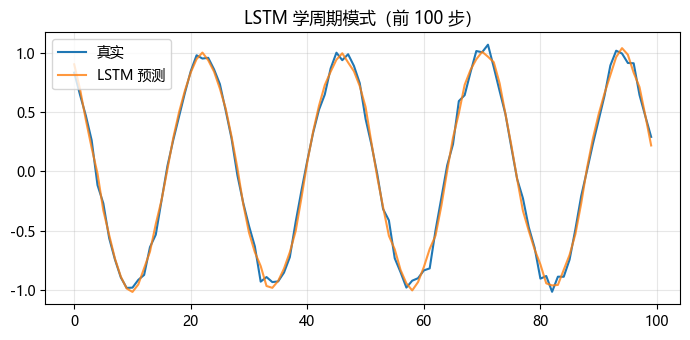

In [6]:
# ---------- 实验 6：用 LSTM 学一个周期模式（玩具验证“能学”） ----------
# 任务：输入过去 8 步，预测下一步（sin 序列）
rng = np.random.default_rng(0)
T = 300
s = np.sin(np.arange(T) * 2 * np.pi / 24) + 0.05 * rng.normal(size=T)
win = 8
X = np.stack([s[i:i + win] for i in range(T - win)]).astype('float32')      # (n, win)
Y = s[win:].astype('float32')
xt = torch.from_numpy(X[:, :, None])                                        # (n, win, 1)
yt = torch.from_numpy(Y)

torch.manual_seed(0)
model = nn.LSTM(1, 16, batch_first=True)
head = nn.Linear(16, 1)
opt = torch.optim.Adam(list(model.parameters()) + list(head.parameters()), lr=1e-2)
for ep in range(120):
    opt.zero_grad()
    h, _ = model(xt)
    pred = head(h[:, -1]).squeeze(-1)
    loss = nn.functional.mse_loss(pred, yt)
    loss.backward(); opt.step()
with torch.no_grad():
    pred = head(model(xt)[0][:, -1]).squeeze(-1).numpy()
mse = np.mean((pred - Y) ** 2)
print('LSTM 一步预测 MSE = %.4f（sin 方差 ≈ %.2f → 已学到结构）' % (mse, Y.var()))

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(7, 3.5))
plt.plot(Y[:100], label='真实'); plt.plot(pred[:100], label='LSTM 预测', alpha=0.8)
plt.title('LSTM 学周期模式（前 100 步）'); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 2. 面试高频追问

1. **为什么 RNN 用 tanh 不用 ReLU**：ReLU 会让正反馈迭代发散（h 无界），tanh 有界稳定
2. **LSTM 的梯度高速公路**：c_t = f⊙c_{t-1} + i⊙g → ∂c_t/∂c_{t-1} ≈ f（遗忘门），一条以加性为主的通路
3. **遗忘门偏置为什么初始化为正**（1~2）：初始倾向“记住”，避免训练初期忘光
4. **GRU vs LSTM**：GRU 无细胞态、参数少 25%、两门；大数据/长依赖 LSTM 略稳，小数据 GRU 更省
5. **双向意义**：正向看过去、反向看未来 → 编码器/序列标注收益大；生成任务不能双向（泄漏未来）

## 3. 自测清单

- [ ] 能手写 RNN/LSTM/GRU 前向公式并解释每个门的语义
- [ ] 能说出 nn.LSTM 权重排布（i,f,g,o 各 H 行）并手写对照
- [ ] 能解释梯度消失的机制与 LSTM 缓解原理（加性细胞 + 遗忘门）
- [ ] 能设计梯度消失实验（长序列回传到 x_0 的梯度范数）
- [ ] 能指出双向 LSTM 输出是正向+反向拼接（2H）及不能用于生成的原因

## 🎤 面试速答（背诵骨架）

- **RNN**：h_t = tanh(Wh·h + Wx·x + b)，参数共享，BPTT 反传
- **LSTM 四门**：i 写入 / f 遗忘 / g 候选 / o 输出；细胞 c 加性更新防消失
- **GRU 两门**：z 更新 (1−z)n+zh、r 重置；少 25% 参数
- **双向**：2H 拼接；序列标注/编码用、生成不用
- **初始化**：遗忘门偏置 1~2；h 初始化 0
